In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

In [2]:
# Read image in grayscale
image = cv2.imread("cat.png", cv2.IMREAD_GRAYSCALE)

In [3]:
# Manual Sobel

sobel_x = np.array([[-1,0,1],
                    [-2,0,2],
                    [-1,0,1]])

sobel_y = np.array([[-1,-2,-1],
                    [0,0,0],
                    [1,2,1]])

gx = convolve2d(image, sobel_x, mode='same')
gy = convolve2d(image, sobel_y, mode='same')

manual_sobel = np.sqrt(gx**2 + gy**2)
manual_sobel = np.uint8(np.clip(manual_sobel,0,255))

In [4]:
# Built-in Sobel

gx_cv = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
gy_cv = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)

builtin_sobel = cv2.magnitude(gx_cv, gy_cv)
builtin_sobel = np.uint8(np.clip(builtin_sobel,0,255))

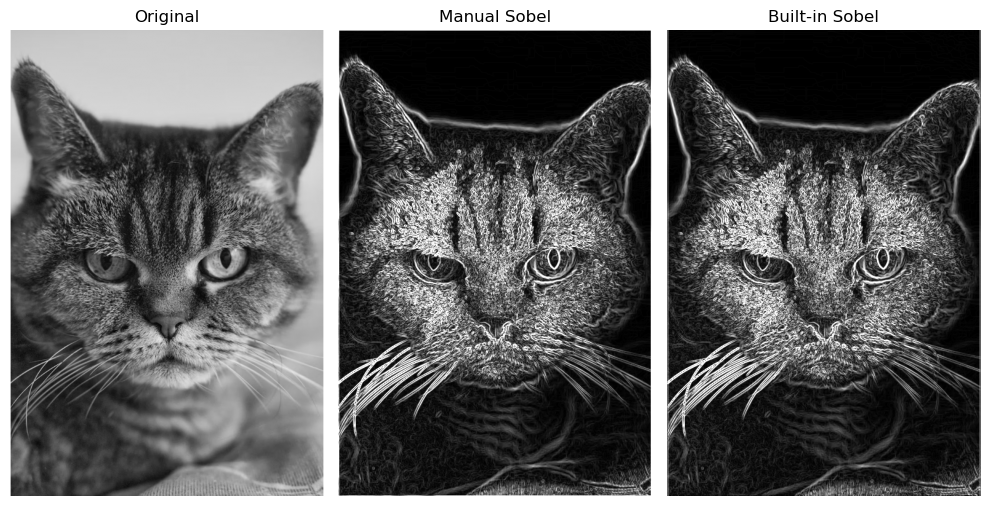

In [5]:
# Sobel Comparison
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(manual_sobel, cmap='gray')
plt.title("Manual Sobel")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(builtin_sobel, cmap='gray')
plt.title("Built-in Sobel")
plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
# Manual Prewitt

prewitt_x = np.array([[-1,0,1],
                      [-1,0,1],
                      [-1,0,1]])

prewitt_y = np.array([[-1,-1,-1],
                      [0,0,0],
                      [1,1,1]])

gx = convolve2d(image, prewitt_x, mode='same')
gy = convolve2d(image, prewitt_y, mode='same')

manual_prewitt = np.sqrt(gx**2 + gy**2)
manual_prewitt = np.uint8(np.clip(manual_prewitt,0,255))

In [7]:
# Built-in Prewitt

gx_cv = cv2.filter2D(image, cv2.CV_64F, prewitt_x)
gy_cv = cv2.filter2D(image, cv2.CV_64F, prewitt_y)

builtin_prewitt = cv2.magnitude(gx_cv, gy_cv)
builtin_prewitt = np.uint8(np.clip(builtin_prewitt,0,255))

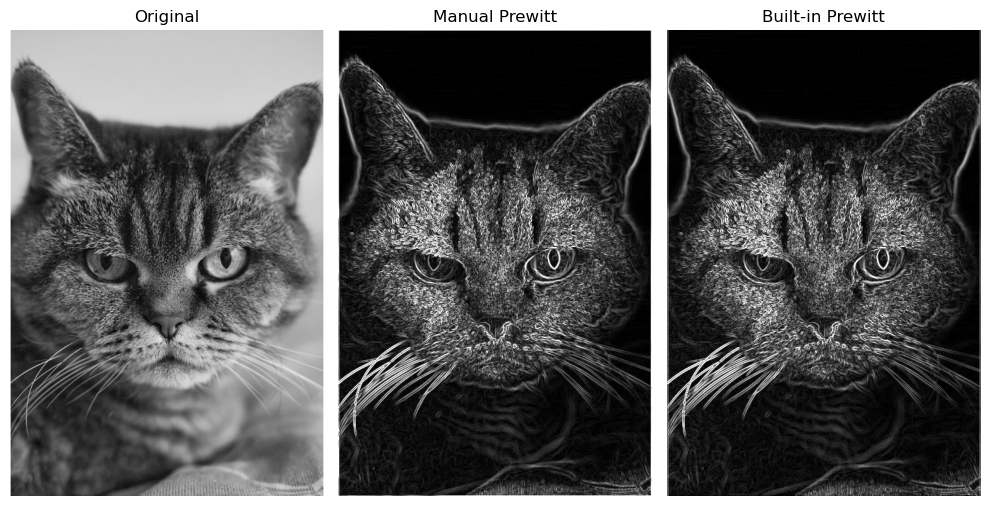

In [8]:
# Prewitt Comparison

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(manual_prewitt, cmap='gray')
plt.title("Manual Prewitt")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(builtin_prewitt, cmap='gray')
plt.title("Built-in Prewitt")
plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
# Manual Roberts Cross

roberts_x = np.array([[1,0],
                      [0,-1]])

roberts_y = np.array([[0,1],
                      [-1,0]])

gx = convolve2d(image, roberts_x, mode='same')
gy = convolve2d(image, roberts_y, mode='same')

manual_roberts = np.sqrt(gx**2 + gy**2)
manual_roberts = np.uint8(np.clip(manual_roberts,0,255))

In [10]:
# Built-in Roberts

gx_cv = cv2.filter2D(image, cv2.CV_64F, roberts_x)
gy_cv = cv2.filter2D(image, cv2.CV_64F, roberts_y)

builtin_roberts = cv2.magnitude(gx_cv, gy_cv)
builtin_roberts = np.uint8(np.clip(builtin_roberts,0,255))

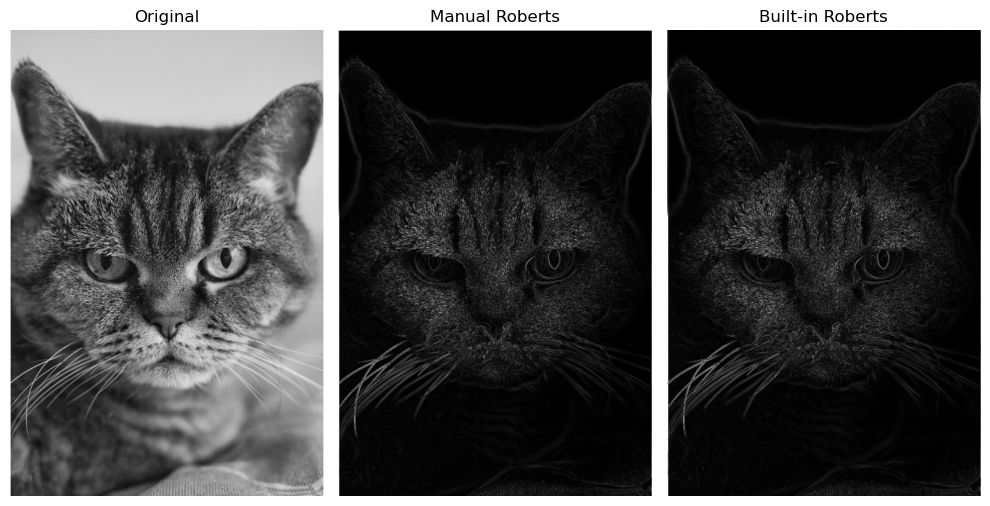

In [11]:
# Roberts Comparison

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(manual_roberts, cmap='gray')
plt.title("Manual Roberts")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(builtin_roberts, cmap='gray')
plt.title("Built-in Roberts")
plt.axis("off")

plt.tight_layout()
plt.show()

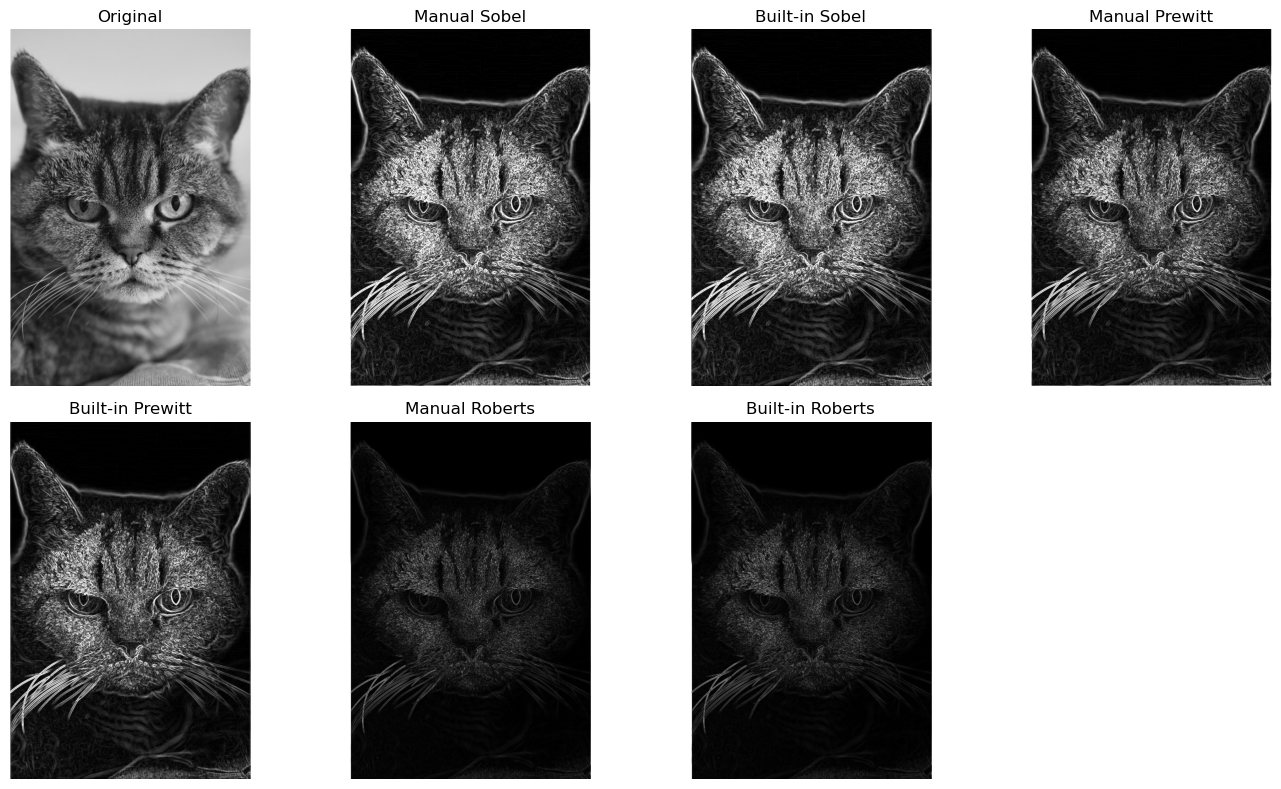

In [12]:
# Display Results

titles = [
    "Original",
    "Manual Sobel",
    "Built-in Sobel",
    "Manual Prewitt",
    "Built-in Prewitt",
    "Manual Roberts",
    "Built-in Roberts"
]

images = [
    image,
    manual_sobel,
    builtin_sobel,
    manual_prewitt,
    builtin_prewitt,
    manual_roberts,
    builtin_roberts
]

plt.figure(figsize=(14,8))

for i in range(len(images)):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()